# Minimal SC-FC Coupling Demo

This notebook builds a minimal runnable example for SC-FC coupling with simulated ROIxROI matrices.

Communication modes from SC:
- Communicability (Crofts & Higham, 2009): `G = exp(D^{-1/2} A D^{-1/2})`
- Mean First Passage Time (Noh & Rieger, 2004)
- Flow graph (Lambiotte et al., 2011), `time_scale = 1`

Node-wise coupling model (multi-linear): predict each node's FC profile from SC-derived predictors, and use adjusted R^2 as coupling strength.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _safe_offdiag_zscore(M, eps=1e-12):
    n = M.shape[0]
    out = M.copy().astype(float)
    mask = ~np.eye(n, dtype=bool)
    x = out[mask]
    mu = x.mean()
    sd = x.std()
    if sd < eps:
        sd = 1.0
    out[mask] = (x - mu) / sd
    np.fill_diagonal(out, 0.0)
    return out


def _sym_matrix_exp(M):
    # Symmetric matrix exponential via eigendecomposition
    w, v = np.linalg.eigh((M + M.T) / 2.0)
    ew = np.exp(w)
    return (v * ew) @ v.T


def simulate_sc_matrix(n_roi, rng, sparsity=0.75):
    # Random weighted undirected SC with a weak ring backbone for connectivity
    W = rng.uniform(0.0, 1.0, size=(n_roi, n_roi))
    W = (W + W.T) / 2.0

    keep = rng.uniform(0.0, 1.0, size=(n_roi, n_roi)) > sparsity
    keep = np.triu(keep, 1)
    keep = keep + keep.T

    A = W * keep

    # ring backbone
    for i in range(n_roi):
        j = (i + 1) % n_roi
        A[i, j] = max(A[i, j], 0.2)
        A[j, i] = A[i, j]

    np.fill_diagonal(A, 0.0)
    return A


def communicability(A, eps=1e-12):
    s = A.sum(axis=1)
    d_inv_sqrt = 1.0 / np.sqrt(np.maximum(s, eps))
    A_norm = (d_inv_sqrt[:, None] * A) * d_inv_sqrt[None, :]
    G = _sym_matrix_exp(A_norm)
    np.fill_diagonal(G, 0.0)
    return G


def flow_graph(A, t=1.0, eps=1e-12):
    # Symmetric normalized Laplacian implementation
    s = A.sum(axis=1)
    d_inv_sqrt = 1.0 / np.sqrt(np.maximum(s, eps))
    A_norm = (d_inv_sqrt[:, None] * A) * d_inv_sqrt[None, :]
    L_sym = np.eye(A.shape[0]) - A_norm
    E = _sym_matrix_exp(-t * L_sym)
    G = E * s[None, :]
    G = (G + G.T) / 2.0
    np.fill_diagonal(G, 0.0)
    return G


def mfpt(A, eps=1e-12):
    # MFPT for random walk with transition matrix P = D^{-1}A
    n = A.shape[0]
    s = A.sum(axis=1)
    P = A / np.maximum(s[:, None], eps)

    T = np.zeros((n, n), dtype=float)
    I = np.eye(n - 1)

    for target in range(n):
        idx = [k for k in range(n) if k != target]
        Q = P[np.ix_(idx, idx)]
        # (I - Q) h = 1
        h = np.linalg.solve(I - Q, np.ones(n - 1))
        T[idx, target] = h

    np.fill_diagonal(T, 0.0)
    return T


def build_fc_from_sc(A, rng, noise_scale=0.25):
    # Build synthetic FC from SC communication predictors + noise
    C = communicability(A)
    F = flow_graph(A, t=1.0)
    M = mfpt(A)

    A_z = _safe_offdiag_zscore(A)
    C_z = _safe_offdiag_zscore(C)
    F_z = _safe_offdiag_zscore(F)
    M_inv_z = _safe_offdiag_zscore(1.0 / (1.0 + M))

    FC = 0.45 * A_z + 0.25 * C_z + 0.20 * F_z + 0.10 * M_inv_z
    FC += noise_scale * rng.normal(size=FC.shape)
    FC = (FC + FC.T) / 2.0
    np.fill_diagonal(FC, 0.0)
    return FC


def adjusted_r2(y, y_hat, n_pred):
    n = y.size
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else 0.0
    denom = n - n_pred - 1
    if denom <= 0:
        return np.nan
    return 1.0 - (1.0 - r2) * (n - 1) / denom


def sc_fc_coupling_one_subject(A, FC):
    C = communicability(A)
    F = flow_graph(A, t=1.0)
    M = mfpt(A)
    M_inv = 1.0 / (1.0 + M)

    n = A.shape[0]
    node_adj_r2 = np.zeros(n, dtype=float)

    for i in range(n):
        mask = np.arange(n) != i
        y = FC[i, mask]
        X = np.column_stack([
            A[i, mask],
            C[i, mask],
            F[i, mask],
            M_inv[i, mask],
        ])

        # z-score each predictor column
        X = (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, keepdims=True) + 1e-12)

        X_aug = np.column_stack([np.ones(X.shape[0]), X])
        beta, *_ = np.linalg.lstsq(X_aug, y, rcond=None)
        y_hat = X_aug @ beta
        node_adj_r2[i] = adjusted_r2(y, y_hat, n_pred=X.shape[1])

    return node_adj_r2


In [6]:
# Simulate a small group and compute SC-FC coupling
rng = np.random.default_rng(42)
n_subjects = 6
n_roi = 40

sc_group = []
fc_group = []
node_couplings = []

for _ in range(n_subjects):
    sc = simulate_sc_matrix(n_roi, rng=rng, sparsity=0.75)
    fc = build_fc_from_sc(sc, rng=rng, noise_scale=0.25)

    sc_group.append(sc)
    fc_group.append(fc)
    node_couplings.append(sc_fc_coupling_one_subject(sc, fc))

sc_group = np.stack(sc_group, axis=0)
fc_group = np.stack(fc_group, axis=0)
node_couplings = np.stack(node_couplings, axis=0)

subject_mean_coupling = np.nanmean(node_couplings, axis=1)

print('SC group shape:', sc_group.shape)   # (subjects, roi, roi)
print('FC group shape:', fc_group.shape)   # (subjects, roi, roi)
print('Node coupling shape:', node_couplings.shape)

summary = pd.DataFrame({
    'subject': np.arange(n_subjects),
    'mean_adjusted_r2': subject_mean_coupling,
})
summary


SC group shape: (6, 40, 40)
FC group shape: (6, 40, 40)
Node coupling shape: (6, 40)


,subject,mean_adjusted_r2
0,0,0.959785
1,1,0.964100
2,2,0.963719
3,3,0.967014
4,4,0.965819
5,5,0.963028


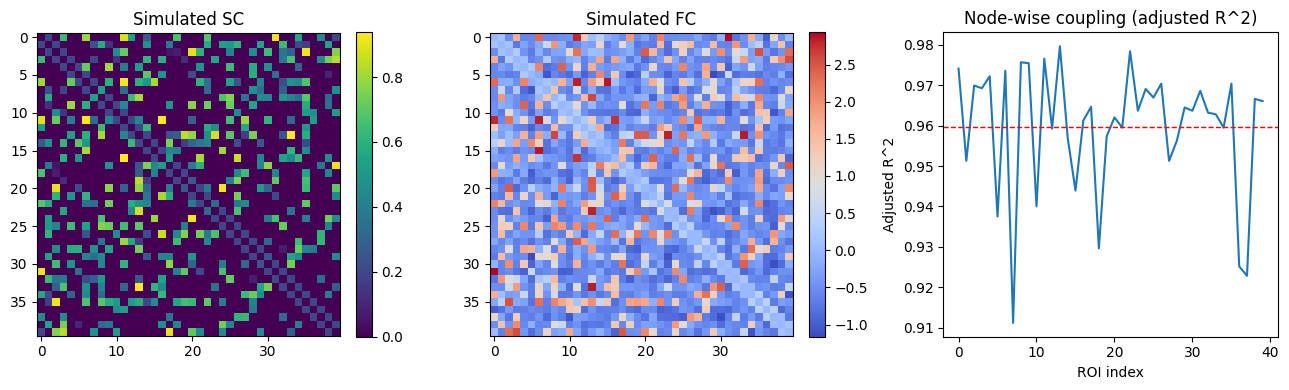

In [9]:
# Quick visualization for subject 0
sid = 0
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

im0 = axes[0].imshow(sc_group[sid], cmap='viridis')
axes[0].set_title('Simulated SC')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(fc_group[sid], cmap='coolwarm')
axes[1].set_title('Simulated FC')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

axes[2].plot(node_couplings[sid], lw=1.5)
axes[2].set_title('Node-wise coupling (adjusted R^2)')
axes[2].set_xlabel('ROI index')
axes[2].set_ylabel('Adjusted R^2')
axes[2].axhline(np.nanmean(node_couplings[sid]), color='r', ls='--', lw=1)

plt.tight_layout()
plt.show()
